# 05 - Multi-Format Input Pipeline

Notebook này giúp bạn **nhìn thấy và đánh giá** hai tầng:

1. **Extraction (ingest):** TXT / DOCX / PDF → `cleaned_text` + số câu (so với paste text baseline)
2. **Summarization:** cùng engine → summary → ROUGE so với gold VietNews

Dùng **cùng code** với API production (`process_from_bytes`, loaders, summarizer).

| Phần | Mục đích |
|------|----------|
| §2 | Thí nghiệm **1 bài** — xem trích xuất + summary từng định dạng |
| §3 | Smoke batch `n=5` |
| §4–5 | Số official `n=200` (chạy script terminal) + case study |

**Script official:** `python scripts/eval_multiformat_vietnews_file_formats.py --n 200 --engine textrank --max-sentences 2 --seed 42 --article-char-threshold 1200 --warmup-engine`

## 1. Setup

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
BACKEND_ROOT = PROJECT_ROOT / "backend"
EVAL_ROOT = PROJECT_ROOT / "evaluation"
for p in (PROJECT_ROOT, BACKEND_ROOT, EVAL_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from scripts.shared.multiformat_experiment import (
    BASELINE_FORMAT,
    MultiformatEvalConfig,
    display_extraction_table,
    display_extracted_text_from_pipeline,
    display_extracted_text_per_format,
    display_format_charts,
    display_ingestion_diff,
    display_multiformat_summary_table,
    display_pipeline_walkthrough,
    display_real_file_evaluation,
    display_summary_evaluation_table,
    display_summary_vs_gold,
    evaluate_article_all_formats,
    evaluate_real_file_for_guid,
    export_vietnews_article_files,
    find_latest_multiformat_artifacts,
    load_multiformat_subset,
    load_vietnews_record_by_guid,
    process_article_all_formats,
    run_multiformat_eval,
)

CONFIG = MultiformatEvalConfig(engine="textrank", subset_limit=5, max_sentences=2)
print("PROJECT_ROOT:", PROJECT_ROOT)
print(CONFIG.as_metadata())

PROJECT_ROOT: D:\Text_Summarization
{'engine': 'textrank', 'protocol_version': 'phase0_v2', 'target_split': 'validation', 'seed': 42, 'subset_limit': 5, 'max_sentences': 2, 'article_char_threshold': 1200, 'warmup_engine': False}


## 2. Thí nghiệm một bài VietNews

Chọn 1 bài từ validation (cùng `seed=42` như benchmark). Mỗi định dạng file được **tạo giả lập trong RAM** từ `article` rồi đọc lại qua loader — giống user upload.

In [2]:
subset = load_multiformat_subset(MultiformatEvalConfig(subset_limit=1, seed=CONFIG.seed))
sample = subset.iloc[0]
article = str(sample["article"])
reference = str(sample["reference_summary"])
guid = sample.get("guid", "")

print("guid:", guid)
print("article chars:", len(article))
print("reference (gold) chars:", len(reference))

guid: 494
article chars: 1598
reference (gold) chars: 142


### 2A. Extraction — text sau loader (trước khi summary)

Bảng metric ingest + đoạn `cleaned_text` thực tế mà engine nhận.

In [3]:
pipeline = process_article_all_formats(article)
display_pipeline_walkthrough(pipeline, preview_chars=300)
display_extracted_text_from_pipeline(pipeline, max_chars=700)

,format,source_type,sentences,cleaned_chars,ingest_rougeL_f,exact_match,replacement_chars,preview
0,text_baseline,text,15,1598,1.0,True,0,"Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự..."
1,file_txt,txt,15,1598,1.0,True,0,"Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự..."
2,file_docx,docx,15,1598,1.0,True,0,"Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự..."
3,file_pdf,pdf,53,1598,1.0,False,0,"T?i 13/5 , thông_tin t? phòng C?nh_sát hình_s?..."


### `text_baseline` — process_from_text (paste / API text)
- chars: 1598 | sentences: 15 | ingest ROUGE-L vs baseline: 1.0000 | exact match: True

```
Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. HCM gặp mặt , xin lỗi anh Nguyễn Sỹ Đức ( PV truyền hình ANTV tại Đắk Lắk ) . Trước đó , chiều 4/5 anh Đức liên tục nhận được điện thoại từ 4 số lạ gọi đến với nội dung đe dọa đến bản thân anh và gia đình của anh . Theo anh Đức , thời_gian qua , đã đưa tin , phản ánh nhiều vụ việc phức tạp , tiêu_cực , ảnh hưởng đến quyền lợi của một số cá nhân , tổ_chức nên nghi_ngờ bị kẻ xấu đe_đoạ , trả_thù . Do_đó , anh Đức đã đến phòng Cảnh sát hình sự Công_an tỉnh Đắk_Lắk trình_báo . Sau khi tiếp_nhận trình_báo , b…
```

### `file_txt` — load_txt_bytes → chardet decode
- chars: 1598 | sentences: 15 | ingest ROUGE-L vs baseline: 1.0000 | exact match: True

```
Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. HCM gặp mặt , xin lỗi anh Nguyễn Sỹ Đức ( PV truyền hình ANTV tại Đắk Lắk ) . Trước đó , chiều 4/5 anh Đức liên tục nhận được điện thoại từ 4 số lạ gọi đến với nội dung đe dọa đến bản thân anh và gia đình của anh . Theo anh Đức , thời_gian qua , đã đưa tin , phản ánh nhiều vụ việc phức tạp , tiêu_cực , ảnh hưởng đến quyền lợi của một số cá nhân , tổ_chức nên nghi_ngờ bị kẻ xấu đe_đoạ , trả_thù . Do_đó , anh Đức đã đến phòng Cảnh sát hình sự Công_an tỉnh Đắk_Lắk trình_báo . Sau khi tiếp_nhận trình_báo , b…
```

### `file_docx` — load_docx_bytes → paragraphs + tables
- chars: 1598 | sentences: 15 | ingest ROUGE-L vs baseline: 1.0000 | exact match: True

```
Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. HCM gặp mặt , xin lỗi anh Nguyễn Sỹ Đức ( PV truyền hình ANTV tại Đắk Lắk ) . Trước đó , chiều 4/5 anh Đức liên tục nhận được điện thoại từ 4 số lạ gọi đến với nội dung đe dọa đến bản thân anh và gia đình của anh . Theo anh Đức , thời_gian qua , đã đưa tin , phản ánh nhiều vụ việc phức tạp , tiêu_cực , ảnh hưởng đến quyền lợi của một số cá nhân , tổ_chức nên nghi_ngờ bị kẻ xấu đe_đoạ , trả_thù . Do_đó , anh Đức đã đến phòng Cảnh sát hình sự Công_an tỉnh Đắk_Lắk trình_báo . Sau khi tiếp_nhận trình_báo , b…
```

### `file_pdf` — load_pdf_bytes → PyMuPDF page.get_text
- chars: 1598 | sentences: 53 | ingest ROUGE-L vs baseline: 1.0000 | exact match: False

```
T?i 13/5 , thông_tin t? phòng C?nh_sát hình_s? , Công_an t?nh ??k_L?k cho bi?t , chi?u cùng ngày ??n_v? ?ã
??a ??i_t??ng Nguy?n Hoàng Quân_Nhi , 23 tu?i , nhân_viên công_ty ?òi n? thuê ? TP. HCM g?p m?t , xin l?i
anh Nguy?n S? ??c ( PV truy?n hình ANTV t?i ??k L?k ) . Tr??c ?ó , chi?u 4/5 anh ??c liên t?c nh?n ???c ?i?n
tho?i t? 4 s? l? g?i ??n v?i n?i dung ?e d?a ??n b?n thân anh và gia ?ình c?a anh . Theo anh ??c , th?i_gian
qua , ?ã ??a tin , ph?n ánh nhi?u v? vi?c ph?c t?p , tiêu_c?c , ?nh h??ng ??n quy?n l?i c?a m?t s? cá nhân ,
t?_ch?c nên nghi_ng? b? k? x?u ?e_?o? , tr?_thù . Do_?ó , anh ??c ?ã ??n phòng C?nh sát hình s? Công_an
t?nh ??k_L?k trình_báo . Sau khi ti?p_nh?n trình_báo , b…
```

In [4]:
baseline_text = pipeline[BASELINE_FORMAT]["cleaned_text"]
for fmt in ("file_txt", "file_docx", "file_pdf"):
    if pipeline[fmt].get("ingest_exact_match"):
        print(f"{fmt}: exact match with text_baseline")
    else:
        print(f"--- diff {fmt} vs baseline ---")
        display_ingestion_diff(baseline_text, pipeline[fmt]["cleaned_text"], format_label=fmt)

file_txt: exact match with text_baseline
file_docx: exact match with text_baseline
--- diff file_pdf vs baseline ---


```diff
--- text_baseline
+++ file_pdf
@@ -1 +1,16 @@
-Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. HCM gặp mặt , xin lỗi anh Nguyễn Sỹ Đức ( PV truyền hình ANTV tại Đắk Lắk ) . Trước đó , chiều 4/5 anh Đức liên tục nhận được điện thoại từ 4 số lạ gọi đến với nội dung đe dọa đến bản thân anh và gia đình của anh . Theo anh Đức , thời_gian qua , đã đưa tin , phản ánh nhiều vụ việc phức tạp , tiêu_cực , ảnh hưởng đến quyền lợi của một số cá nhân , tổ_chức nên nghi_ngờ bị kẻ xấu đe_đoạ , trả_thù . Do_đó , anh Đức đã đến phòng Cảnh sát hình sự Công_an tỉnh Đắk_Lắk trình_báo . Sau khi tiếp_nhận trình_báo , bằng các biện_pháp nghiệp lực_lượng Công_an tỉnh Đắk_Lắk xác_định được đối tượng đe_doạ anh Đức là Nguyễn_Hoàng_Quân_Nhi , hiện đang ở quận 11 , TP. Hồ_Chí_Minh . Ngay sau đó , một tổ công_tác của phòng Cảnh_sát hình_sự được cử xuống TP. Hồ_Chí_Minh để xác minh , và mời đối tượng Nhi về trụ sở Công_an tỉnh Đắk Lắk để làm việc . Tại cơ_quan công_an , đối_tượng Nhi khai nhận mình là nhân_viên một công_ty đòi nợ thuê ở TP. Hồ_Chí_Minh . Ngày 4/5 , Nhi nhận nhiệm vụ đòi nợ một người có tên Nguyễn Minh Đức , nhưng quá_trình tìm số điện_thoại đã nhầm lẫn sang số điện_thoại của anh Nguyễn Sỹ Đức . Sau đó , Nhi dùng nhiều số điện_thoại của công_ty và cá_nhân gọi vào số máy của anh Đức đe dọa , nhằm mục đích đòi nợ , nhưng nhầm người . Tại cơ_quan công_an , Nhi đã xin_lỗi anh Đức và mong anh thông_cảm vì sự nhầm_lẫn của mình . Đối_tượng Nhi đã nhiều lần gọi điện đe_doạ phóng_viên Nguyễn_Sỹ_Đức .
+T?i 13/5 , thông_tin t? phòng C?nh_sát hình_s? , Công_an t?nh ??k_L?k cho bi?t , chi?u cùng ngày ??n_v? ?ã
+??a ??i_t??ng Nguy?n Hoàng Quân_Nhi , 23 tu?i , nhân_viên công_ty ?òi n? thuê ? TP. HCM g?p m?t , xin l?i
+anh Nguy?n S? ??c ( PV truy?n hình ANTV t?i ??k L?k ) . Tr??c ?ó , chi?u 4/5 anh ??c liên t?c nh?n ???c ?i?n
+tho?i t? 4 s? l? g?i ??n v?i n?i dung ?e d?a ??n b?n thân anh và gia ?ình c?a anh . Theo anh ??c , th?i_gian
+qua , ?ã ??a tin , ph?n ánh nhi?u v? vi?c ph?c t?p , tiêu_c?c , ?nh h??ng ??n quy?n l?i c?a m?t s? cá nhân ,
+t?_ch?c nên nghi_ng? b? k? x?u ?e_?o? , tr?_thù . Do_?ó , anh ??c ?ã ??n phòng C?nh sát hình s? Công_an
+t?nh ??k_L?k trình_báo . Sau khi ti?p_nh?n trình_báo , b?ng các bi?n_pháp nghi?p l?c_l??ng Công_an t?nh
+??k_L?k xác_??nh ???c ??i t??ng ?e_do? anh ??c là Nguy?n_Hoàng_Quân_Nhi , hi?n ?ang ? qu?n 11 , TP.
+H?_Chí_Minh . Ngay sau ?ó , m?t t? công_tác c?a phòng C?nh_sát hình_s? ???c c? xu?ng TP. H?_Chí_Minh
+?? xác minh , và m?i ??i t??ng Nhi v? tr? s? Công_an t?nh ??k L?k ?? làm vi?c . T?i c?_quan công_an ,
+??i_t??ng Nhi khai nh?n mình là nhân_viên m?t công_ty ?òi n? thuê ? TP. H?_Chí_Minh . Ngày 4/5 , Nhi nh?n
+nhi?m v? ?òi n? m?t ng??i có tên Nguy?n Minh ??c , nh?ng quá_trình tìm s? ?i?n_tho?i ?ã nh?m l?n sang s?
+?i?n_tho?i c?a anh Nguy?n S? ??c . Sau ?ó , Nhi dùng nhi?u s? ?i?n_tho?i c?a công_ty và cá_nhân g?i vào s?
+máy c?a anh ??c ?e d?a , nh?m m?c ?ích ?òi n? , nh?ng nh?m ng??i . T?i c?_quan công_an , Nhi ?ã xin_l?i
+anh ??c và mong anh thông_c?m vì s? nh?m_l?n c?a mình . ??i_t??ng Nhi ?ã nhi?u l?n g?i ?i?n ?e_do?
+phóng_viên Nguy?n_S?_??c .
```

### 2B. Summarization — ROUGE summary vs gold (mọi định dạng)

Một lần chạy: ingest + TextRank `top_k=2` + ROUGE so `reference_summary`.

In [5]:
experiment_df = evaluate_article_all_formats(
    article,
    reference,
    engine=CONFIG.engine,
    max_sentences=CONFIG.max_sentences,
)
display_extraction_table(experiment_df)
display_summary_evaluation_table(experiment_df)
display_summary_vs_gold(experiment_df, max_chars=700)

,format,loader,source_type,cleaned_char_length,sentence_count,ingest_exact_match,ingest_char_len_ratio,ingest_sentence_count_delta,ingest_rougeL_f,ingest_replacement_char_count,ingest_latency_sec
0,text_baseline,process_from_text (paste / API text),text,1598,15,True,1.0,0,1.0,0,0.000133
1,file_txt,load_txt_bytes → chardet decode,txt,1598,15,True,1.0,0,1.0,0,0.003461
2,file_docx,load_docx_bytes → paragraphs + tables,docx,1598,15,True,1.0,0,1.0,0,0.021147
3,file_pdf,load_pdf_bytes → PyMuPDF page.get_text,pdf,1598,53,False,1.0,38,1.0,0,0.014238


,format,rouge1_f,rouge2_f,rougeL_f,rougeL_delta_vs_baseline,compression_ratio,repetition_rate,summarize_latency_sec
0,text_baseline,0.445783,0.146341,0.277108,0.000000,0.230914,0.030769,0.002138
1,file_txt,0.445783,0.146341,0.277108,0.000000,0.230914,0.030769,0.002880
2,file_docx,0.445783,0.146341,0.277108,0.000000,0.230914,0.030769,0.001848
3,file_pdf,0.422222,0.090909,0.266667,-0.010442,0.076971,0.000000,0.015987


### Summary `text_baseline` — ROUGE-L=0.2771

**Predicted (369 chars):**
```
Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. Sau khi tiếp_nhận trình_báo , bằng các biện_pháp nghiệp lực_lượng Công_an tỉnh Đắk_Lắk xác_định được đối tượng đe_doạ anh Đức là Nguyễn_Hoàng_Quân_Nhi , hiện đang ở quận 11 , TP.
```

**Gold reference (142 chars):**
```
Một đối_tượng là nhân_viên đòi nợ thuê khai xác_minh nhầm phóng_viên ANTV là con_nợ nên đã nhiều lần gọi điện đe_doạ gia_đình phóng_viên này .
```

...

**Predicted (369 chars):**
```
Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. Sau khi tiếp_nhận trình_báo , bằng các biện_pháp nghiệp lực_lượng Công_an tỉnh Đắk_Lắk xác_định được đối tượng đe_doạ anh Đức là Nguyễn_Hoàng_Quân_Nhi , hiện đang ở quận 11 , TP.
```

### Summary `file_docx` — ROUGE-L=0.2771 (Δ vs baseline=+0.0000)

**Predicted (369 chars):**
```
Tối 13/5 , thông_tin từ phòng Cảnh_sát hình_sự , Công_an tỉnh Đắk_Lắk cho biết , chiều cùng ngày đơn_vị đã đưa đối_tượng Nguyễn Hoàng Quân_Nhi , 23 tuổi , nhân_viên công_ty đòi nợ thuê ở TP. Sau khi tiếp_nhận trình_báo , bằng các biện_pháp nghiệp lực_lượng Công_an tỉnh Đắk_Lắk xác_định được đối tượng đe_doạ anh Đức là Nguyễn_Hoàng_Quân_Nhi , hiện đang ở quận 11 , TP.
```

### Summary `file_pdf` — ROUGE-L=0.2667 (Δ vs baseline=-0.0104)

**Predicted (123 chars):**
```
Tr??c ?ó , chi?u 4/5 anh ??c liên t?c nh?n ???c ?i?n
tho?i t? vi?c ph?c t?p , tiêu_c?c , ?nh h??ng ??n quy?n l?i c?a m?t s?
```

**Đọc kết quả nhanh:**
- `ingest_rougeL_f` ≈ 1 và `ingest_exact_match=True` → trích xuất giống paste text.
- `rougeL_f` = chất lượng tóm tắt so gold; `rougeL_delta_vs_baseline` = lệch do định dạng (0 = không đổi).

## 3. Smoke eval (n=5)

In [6]:
smoke_df, smoke_report = run_multiformat_eval(
    n=CONFIG.subset_limit,
    engine=CONFIG.engine,
    max_sentences=CONFIG.max_sentences,
    seed=CONFIG.seed,
    protocol_version=CONFIG.protocol_version,
    target_split=CONFIG.target_split,
    article_char_threshold=CONFIG.article_char_threshold,
    warmup_engine=CONFIG.warmup_engine,
)
display_multiformat_summary_table(smoke_df)
print(json.dumps(smoke_report.get("by_format", {}), ensure_ascii=False, indent=2))

,format,n_ok,mean_ingest_rougeL_f,pct_exact_match,mean_rougeL_f,mean_rougeL_delta_vs_baseline
0,file_docx,5,1.0,100.0,0.349924,0.000000
1,file_pdf,5,1.0,0.0,0.276208,-0.073716
2,file_txt,5,1.0,100.0,0.349924,0.000000
3,text_baseline,5,1.0,100.0,0.349924,0.000000


{
  "text_baseline": {
    "n_ok": 5,
    "mean_rougeL_f": 0.34992385497880213,
    "mean_rouge1_f": 0.5021074581619475,
    "mean_rouge2_f": 0.23567838159236248,
    "mean_compression_ratio": 0.12961269916914117,
    "mean_repetition_rate": 0.1930186002522068,
    "mean_cleaned_char_len": 2513.4,
    "mean_ingest_rougeL_f": 1.0,
    "pct_exact_match": 100.0,
    "mean_ingest_char_len_ratio": 1.0,
    "mean_ingest_replacement_char_count": 0.0
  },
  "file_txt": {
    "n_ok": 5,
    "mean_rougeL_f": 0.34992385497880213,
    "mean_rouge1_f": 0.5021074581619475,
    "mean_rouge2_f": 0.23567838159236248,
    "mean_compression_ratio": 0.12961269916914117,
    "mean_repetition_rate": 0.1930186002522068,
    "mean_cleaned_char_len": 2513.4,
    "mean_ingest_rougeL_f": 1.0,
    "pct_exact_match": 100.0,
    "mean_ingest_char_len_ratio": 1.0,
    "mean_ingest_replacement_char_count": 0.0,
    "mean_rougeL_delta_vs_baseline": 0.0
  },
  "file_docx": {
    "n_ok": 5,
    "mean_rougeL_f": 0.349923

## 4. Official artifacts (n=200)

Chạy trong terminal (không chạy 200 trong notebook):

```bash
python scripts/eval_multiformat_vietnews_file_formats.py --n 200 --engine textrank --max-sentences 2 --seed 42 --article-char-threshold 1200 --warmup-engine
```

detail: D:\Text_Summarization\notebooks\results\analysis\multiformat_vietnews_files_detail_20260520_043723.csv
report: D:\Text_Summarization\notebooks\results\analysis\multiformat_vietnews_files_report_20260520_043723.json


,format,n_ok,mean_ingest_rougeL_f,pct_exact_match,mean_rougeL_f,mean_rougeL_delta_vs_baseline
0,file_docx,200,1.000000,100.0,0.320491,0.000000
1,file_pdf,200,0.999842,0.0,0.322538,0.002047
2,file_txt,200,1.000000,100.0,0.320491,0.000000
3,text_baseline,200,1.000000,100.0,0.320491,0.000000


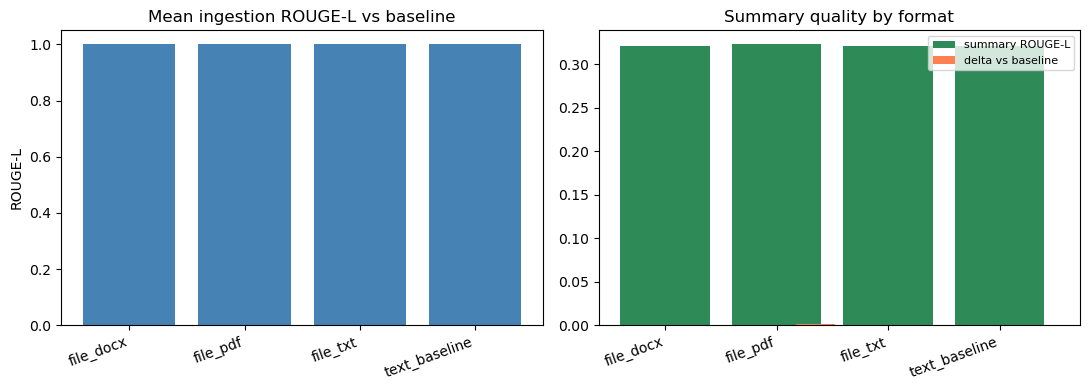

schema: multiformat_vietnews_file_formats_v2
{
  "text_baseline": {
    "n_ok": 200,
    "mean_rougeL_f": 0.32049108667498594,
    "mean_rouge1_f": 0.49813430188724916,
    "mean_rouge2_f": 0.2235846121644839,
    "mean_compression_ratio": 0.1397350085694056,
    "mean_repetition_rate": 0.0989193219892886,
    "mean_cleaned_char_len": 2678.385,
    "mean_ingest_rougeL_f": 1.0,
    "pct_exact_match": 100.0,
    "mean_ingest_char_len_ratio": 1.0,
    "mean_ingest_replacement_char_count": 0.0
  },
  "file_txt": {
    "n_ok": 200,
    "mean_rougeL_f": 0.32049108667498594,
    "mean_rouge1_f": 0.49813430188724916,
    "mean_rouge2_f": 0.2235846121644839,
    "mean_compression_ratio": 0.1397350085694056,
    "mean_repetition_rate": 0.0989193219892886,
    "mean_cleaned_char_len": 2678.385,
    "mean_ingest_rougeL_f": 1.0,
    "pct_exact_match": 100.0,
    "mean_ingest_char_len_ratio": 1.0,
    "mean_ingest_replacement_char_count": 0.0,
    "mean_rougeL_delta_vs_baseline": 0.0
  },
  "file_do

In [7]:
analysis_dir = PROJECT_ROOT / "notebooks" / "results" / "analysis"
detail_path, report_path = find_latest_multiformat_artifacts(analysis_dir)
print("detail:", detail_path)
print("report:", report_path)

if detail_path is None:
    print("Chưa có artifact. Chạy lệnh terminal ở §4.")
else:
    official_df = pd.read_csv(detail_path)
    display_multiformat_summary_table(official_df)
    display_format_charts(official_df)
    if report_path:
        report = json.loads(report_path.read_text(encoding="utf-8"))
        print("schema:", report.get("report_schema"))
        print(json.dumps(report.get("by_format", {}), ensure_ascii=False, indent=2))

## 5. Case study — xem extraction + summary trên 1 guid cụ thể

In [8]:
if detail_path is None:
    print("Cần official CSV (§4).")
else:
    ok = official_df[official_df["status"] == "ok"].copy()
    # guid PDF có ingest thấp nhất (nếu có)
    pdf_rows = ok[ok["format"] == "file_pdf"].sort_values("ingest_rougeL_f")
    case_guid = pdf_rows.iloc[0]["guid"] if not pdf_rows.empty else ok.iloc[0]["guid"]
    print("Case guid:", case_guid)

    case_subset = load_multiformat_subset(MultiformatEvalConfig(subset_limit=500, seed=CONFIG.seed))
    case_row = case_subset[case_subset["guid"] == case_guid].iloc[0]
    case_article = str(case_row["article"])
    case_ref = str(case_row["reference_summary"])

    case_df = evaluate_article_all_formats(
        case_article, case_ref, engine=CONFIG.engine, max_sentences=CONFIG.max_sentences
    )
    display_extraction_table(case_df)
    display_extracted_text_per_format(case_df, max_chars=500)
    display_summary_evaluation_table(case_df)
    display_summary_vs_gold(case_df, max_chars=500)

Case guid: 6131


,format,loader,source_type,cleaned_char_length,sentence_count,ingest_exact_match,ingest_char_len_ratio,ingest_sentence_count_delta,ingest_rougeL_f,ingest_replacement_char_count,ingest_latency_sec
0,text_baseline,process_from_text (paste / API text),text,2413,19,True,1.000000,0,1.000000,0,0.000168
1,file_txt,load_txt_bytes → chardet decode,txt,2413,19,True,1.000000,0,1.000000,0,0.003841
2,file_docx,load_docx_bytes → paragraphs + tables,docx,2413,19,True,1.000000,0,1.000000,0,0.023424
3,file_pdf,load_pdf_bytes → PyMuPDF page.get_text,pdf,2415,64,False,1.000829,45,0.997924,0,0.016806


### `text_baseline` — process_from_text (paste / API text)

```
Loại vi_khuẩn nói trên có khả_năng sống_sót trong một chất hoá_học tên là perchlorate - được tìm thấy ở nhiều loại đất của sao Hoả . Perchlorate làm giảm đáng_kể điểm mức đóng_băng của nước và mang độc_tính rất cao . Vi_khuẩn Planococcus halocryophilus , vốn tồn_tại trong lớp băng vĩnh_cửu ở Bắc_Cực , còn được cho_rằng sẽ ' bình_yên ' ngay cả trên sao_Diêm_Vương và các vệ_tinh quay xung_quanh sao Thổ và sao Mộc . Các nhà_khoa_học tại Đại_học Kỹ_thuật Berlin , Đại_học Tufts , Đại_học hoàng_gia Lo…
```

### `file_txt` — load_txt_bytes → chardet decode

...

**Predicted (255 chars):**
```
Loại vi_khuẩn nói trên có khả_năng sống_sót trong một chất hoá_học tên là perchlorate - được tìm thấy ở nhiều loại đất của sao Hoả . Vi_khuẩn Planococcus halocryophilus có khả_năng sống_sót trong một chất hoá_học được phát_hiện trên sao Hoả - Ảnh : NASA .
```

### Summary `file_docx` — ROUGE-L=0.3419 (Δ vs baseline=+0.0000)

**Predicted (255 chars):**
```
Loại vi_khuẩn nói trên có khả_năng sống_sót trong một chất hoá_học tên là perchlorate - được tìm thấy ở nhiều loại đất của sao Hoả . Vi_khuẩn Planococcus halocryophilus có khả_năng sống_sót trong một chất hoá_học được phát_hiện trên sao Hoả - Ảnh : NASA .
```

### Summary `file_pdf` — ROUGE-L=0.3585 (Δ vs baseline=+0.0166)

**Predicted (211 chars):**
```
Lo?i vi_khu?n nói trên có kh?_n?ng s?ng_sót trong m?t ch?t hoá_h?c tên là perchlorate - ???c tìm th?y ? Vi_khu?n Planococcus halocryophilus có kh?_n?ng s?ng_sót trong m?t ch?t hoá_h?c ???c phát_hi?n trên sao
Ho?
```

## 6. File thật + gold VietNews (cùng `guid`)

**Điều kiện dùng gold:** file phải chứa (gần) đúng `article` của bản ghi VietNews đó.

1. Chọn `guid` (ví dụ từ §5: `6131`).
2. (Tuỳ chọn) Xuất file mẫu từ dataset vào `data/samples/multiformat/`.
3. Đặt file thật (hoặc file vừa xuất) và chạy ô dưới → **ingestion + ROUGE vs `reference_summary`**.

CLI tương đương:

```bash
python scripts/eval_real_file_for_guid.py --guid 6131 --file data/samples/multiformat/6131.docx
```

In [9]:
# --- Tham số: đổi 2 dòng này ---
REAL_FILE_GUID = "6131"  # guid trong VietNews validation
REAL_FILE_PATH = PROJECT_ROOT / "data" / "samples" / "multiformat" / f"{REAL_FILE_GUID}.docx"

samples_dir = PROJECT_ROOT / "data" / "samples" / "multiformat"
EXPORT_SAMPLES = True  # True: ghi lại .txt/.docx/.pdf từ article trong dataset

if EXPORT_SAMPLES:
    samples_dir.mkdir(parents=True, exist_ok=True)
    exported = export_vietnews_article_files(REAL_FILE_GUID, samples_dir)
    print("Exported from dataset:")
    for k, p in exported.items():
        print(f"  {k}: {p}")

file_path = Path(REAL_FILE_PATH)
if not file_path.is_file():
    print(f"File not found: {file_path}")
    print("Set REAL_FILE_PATH or run EXPORT_SAMPLES=True first.")
else:
    result = evaluate_real_file_for_guid(
        REAL_FILE_GUID,
        file_path,
        engine=CONFIG.engine,
        max_sentences=CONFIG.max_sentences,
    )
    display_real_file_evaluation(result, preview_chars=700)

Exported from dataset:
  txt: D:\Text_Summarization\data\samples\multiformat\6131.txt
  docx: D:\Text_Summarization\data\samples\multiformat\6131.docx
  pdf: D:\Text_Summarization\data\samples\multiformat\6131.pdf


### Real file `6131.docx` — guid `6131`
- Path: `D:\Text_Summarization\data\samples\multiformat\6131.docx`
- Source type: `docx` | Engine: `textrank` | top_k: `2`

,branch,cleaned_chars,sentences,rouge1_f,rouge2_f,rougeL_f
0,text_baseline (article in RAM),2413,19,0.581197,0.278261,0.34188
1,real_file (6131.docx),2413,19,0.581197,0.278261,0.34188


#### Ingestion (real file vs text baseline)

,ingest_exact_match,ingest_char_len_ratio,ingest_sentence_count_delta,ingest_rougeL_f,ingest_replacement_char_count,ingest_latency_sec
0,True,1.0,0,1.0,0,0.024891


#### Summary ROUGE vs gold — Δ real vs baseline = +0.0000

**baseline** — ROUGE-L=0.3419
```
Loại vi_khuẩn nói trên có khả_năng sống_sót trong một chất hoá_học tên là perchlorate - được tìm thấy ở nhiều loại đất của sao Hoả . Vi_khuẩn Planococcus halocryophilus có khả_năng sống_sót trong một chất hoá_học được phát_hiện trên sao Hoả - Ảnh : NASA .
```

**real_file** — ROUGE-L=0.3419
```
Loại vi_khuẩn nói trên có khả_năng sống_sót trong một chất hoá_học tên là perchlorate - được tìm thấy ở nhiều loại đất của sao Hoả . Vi_khuẩn Planococcus halocryophilus có khả_năng sống_sót trong một chất hoá_học được phát_hiện trên sao Hoả - Ảnh : NASA .
```

**Gold reference (137 chars):**
```
Tên khoa_học của vi_khuẩn là Planococcus halocryophilus . Khám_phá này giúp giới khoa_học có thêm hi_vọng tìm thấy sự sống trên sao Hoả .
```